## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Travel.csv')

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [4]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [32]:
fet = [feature for feature in df.columns if df[feature].dtypes =='O']
for i in fet:
    print(df[i].value_counts())

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64
Gender
Male      2916
Female    1972
Name: count, dtype: int64
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64


In [33]:
df['Gender']=df['Gender'].replace('Fe Male','Female')

In [35]:
df['Gender'].value_counts('Unmarried','Single')

Gender
Male      0.596563
Female    0.403437
Name: proportion, dtype: float64

In [37]:
df['MaritalStatus']=df['MaritalStatus'].replace('Unmarried','Single')

In [38]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

In [43]:
null_features = [features for features in df.columns if df[features].isnull().sum()>=1]
for features in null_features:
    print(features,np.round(df[features].isnull().mean()*100,5),'%Missing value')

Age 4.62357 %Missing value
TypeofContact 0.51146 %Missing value
DurationOfPitch 5.13502 %Missing value
NumberOfFollowups 0.92062 %Missing value
PreferredPropertyStar 0.53191 %Missing value
NumberOfTrips 2.86416 %Missing value
NumberOfChildrenVisiting 1.35025 %Missing value
MonthlyIncome 4.76678 %Missing value


In [53]:
df[null_features].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000
mean,37.547259,15.362930,3.711129,3.577946,3.229746,1.184738,23559.179419
std,9.104795,8.316166,0.998271,0.797005,1.822769,0.852323,5257.862921
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20485.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,43.000000,19.000000,4.000000,4.000000,4.000000,2.000000,25424.750000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing Null values
1. Impute Median value for Age column
2. Impute Mode for Type of Contract
3. Impute Median for Duration of Pitch
4. Impute Mode for NumberofFollowup as it is Discrete feature
5. Impute Mode for PreferredPropertyStar
6. Impute Median for NumberofTrips
7. Impute Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome

In [51]:
df.Age.fillna(df.Age.median(),inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace = True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [52]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [58]:
df['TotalPersonVisiting'] = df['NumberOfChildrenVisiting']+df['NumberOfPersonVisiting']
df.drop(columns=['CustomerID','NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis =1 ,inplace=True)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   object 
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   object 
 6   Gender                  4888 non-null   object 
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   object 
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   object 
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   

In [88]:
#get numericl features 
num_feat = [features for features in df.columns if df[features].dtype!='O']
print(f'Number fo numeric features: {len(num_feat)}')

Number fo numeric features: 12


In [ ]:
#Categotical features
Cat_feature=[features for features in df.columns if df[features].dtype=='O'] 
print(f'Categotical features: {len(Cat_feature)}')

Categotical features: 6


In [68]:
# descrete features
desc_features  = [features for features in num_feat if len(df[features].unique())<=25]
#continous features 
conti_feat= [features for features in num_feat if features not in desc_features]
print(f'Descrete feature: {len(desc_features)}\nContinous Feature:{len(conti_feat)}')

Descrete feature: 9
Continous Feature:3


In [69]:
df.head(1)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalPersonVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0


In [72]:
#indipendent and dependent feature
X = df.drop('ProdTaken',axis=1)
y= df['ProdTaken']

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.25,train_size=0.35,random_state=30)

In [85]:
cat_feat = X.select_dtypes(include='object').columns
Numeric_feature = X.select_dtypes(exclude='object').columns

In [89]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
stnd_scal = StandardScaler()
one_hot = OneHotEncoder(drop='first')
preprocessing = ColumnTransformer(
    [
        ('OneHotEncoder',one_hot,cat_feat),
        ('standscler',stnd_scal,Numeric_feature)
    ]
)

In [90]:
X_train =preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)

In [93]:
traindf =pd.DataFrame(X_train)
traindf.head(2)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.471925,-0.773167,0.313484,1.804776,-0.661423,-0.63375,1.446367,-1.256656,-0.342554,0.693250
1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.710122,1.201061,0.313484,-0.722797,-0.661423,-0.63375,0.709173,0.795762,-0.392810,-0.031357


# Model Tranning

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [112]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier()
}
models
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    #make prediction X_Train
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Training set performance
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1score= f1_score(y_train,y_train_pred,average='weighted')
    model_train_pre = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_roc = roc_auc_score(y_train,y_train_pred)
    
    #Test set performance 
    model_test_accuracy= accuracy_score(y_test,y_test_pred)
    model_test_f1_score = f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    print('Model performance for Tranning set')
    print('Accuracy: {:.4f}'.format(model_train_accuracy))
    print('f1_score {:.4f}'.format(model_train_f1score))

    print('precision: {:.4f}'.format(model_train_pre))
    print('Recall Score {:.4f}'.format(model_train_recall))
    print('roc_auc_score {:.4f}'.format(model_train_roc))

    print('----------------------------------')

    print('Model performance for Test set')
    print('Accuracy: {:.4f}'.format(model_test_accuracy))
    print('f1_score {:.4f}'.format(model_test_f1_score))

    print('precision: {:.4f}'.format(model_test_precision))
    print('Recall Score {:.4f}'.format(model_test_recall))
    print('roc_auc_score {:.4f}'.format(model_test_roc_auc))

    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Tranning set
Accuracy: 0.8468
f1_score 0.8198
precision: 0.7197
Recall Score 0.2969
roc_auc_score 0.6351
----------------------------------
Model performance for Test set
Accuracy: 0.8429
f1_score 0.8199
precision: 0.6903
Recall Score 0.3319
roc_auc_score 0.6482


Decision Tree
Model performance for Tranning set
Accuracy: 1.0000
f1_score 1.0000
precision: 1.0000
Recall Score 1.0000
roc_auc_score 1.0000
----------------------------------
Model performance for Test set
Accuracy: 0.8241
f1_score 0.8261
precision: 0.5400
Recall Score 0.5745
roc_auc_score 0.7290


Random Forest
Model performance for Tranning set
Accuracy: 1.0000
f1_score 1.0000
precision: 1.0000
Recall Score 1.0000
roc_auc_score 1.0000
----------------------------------
Model performance for Test set
Accuracy: 0.8822
f1_score 0.8698
precision: 0.8273
Recall Score 0.4894
roc_auc_score 0.7325




In [124]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [136]:
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params)
                   
                   ]

In [137]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]})]

In [142]:
from sklearn.model_selection import RandomizedSearchCV
model_parem ={}
for name,model,parems in randomcv_models:
    random=RandomizedSearchCV(
        estimator=model,
        param_distributions=parems,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    random.fit(X_train,y_train)
    model_parem[name]=random.best_params_
for model_name in model_parem:
    print(f'------------------Best Param for {model_name}------------------')
    print(model_parem[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
------------------Best Param for RF------------------
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


In [145]:
models = {
    'Random Forest':RandomForestClassifier(n_estimators= 200, min_samples_split= 2, max_features=8, max_depth=None)
}

In [146]:
for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    #make prediction X_Train
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Training set performance
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1score= f1_score(y_train,y_train_pred,average='weighted')
    model_train_pre = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_roc = roc_auc_score(y_train,y_train_pred)
    
    #Test set performance 
    model_test_accuracy= accuracy_score(y_test,y_test_pred)
    model_test_f1_score = f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    print('Model performance for Tranning set')
    print('Accuracy: {:.4f}'.format(model_train_accuracy))
    print('f1_score {:.4f}'.format(model_train_f1score))

    print('precision: {:.4f}'.format(model_train_pre))
    print('Recall Score {:.4f}'.format(model_train_recall))
    print('roc_auc_score {:.4f}'.format(model_train_roc))

    print('----------------------------------')

    print('Model performance for Test set')
    print('Accuracy: {:.4f}'.format(model_test_accuracy))
    print('f1_score {:.4f}'.format(model_test_f1_score))

    print('precision: {:.4f}'.format(model_test_precision))
    print('Recall Score {:.4f}'.format(model_test_recall))
    print('roc_auc_score {:.4f}'.format(model_test_roc_auc))

    print('='*35)
    print('\n')
    

Random Forest
Model performance for Tranning set
Accuracy: 1.0000
f1_score 1.0000
precision: 1.0000
Recall Score 1.0000
roc_auc_score 1.0000
----------------------------------
Model performance for Test set
Accuracy: 0.8797
f1_score 0.8672
precision: 0.8143
Recall Score 0.4851
roc_auc_score 0.7294




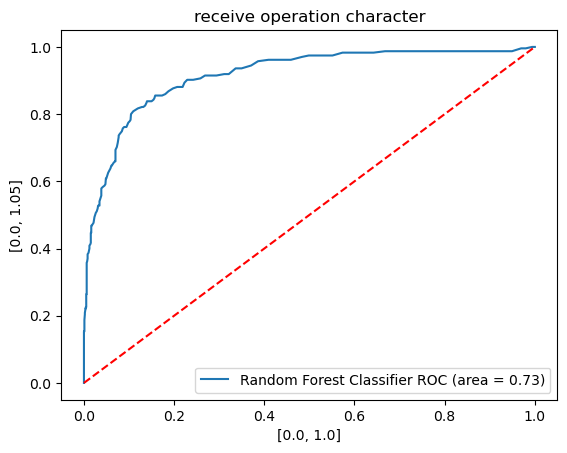

In [150]:
# roc_auc_curve
use_model= [

    {
        'Label':'Random Forest Classifier',
        'Model':RandomForestClassifier(n_estimators= 200, min_samples_split= 2, max_features=8, max_depth=None),
        'auc':0.7294
    }
]
for algo in use_model:
    model=algo['Model']
    model.fit(X_train,y_train)
    fpr, tpr,treshold=roc_curve(y_test,model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['Label'], algo['auc']))
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlabel([0.0,1.0])
    plt.ylabel([0.0,1.05])
    plt.title('receive operation character')
    plt.legend(loc='lower right')
    plt.savefig("auc.png")
    plt.show() 